In [71]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [72]:
columns_headers = [
    "time", "gender", "highschool_%", "study_year","faculty","ung_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
df = pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/Stats survey.csv", names=columns_headers, header=0)

In [ ]:
df.drop(columns="time",axis=1,inplace=True)

In [74]:
df.head()

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [75]:
df.dtypes

gender              object
highschool_%       float64
study_year          object
faculty             object
ung_grade_2023     float64
accomodation        object
allowance           object
scholarship         object
study_hours         object
party_week          object
drinks_night        object
missed_classes      object
failed_classes      object
in_relationship     object
parent_approve      object
relation_parent     object
dtype: object

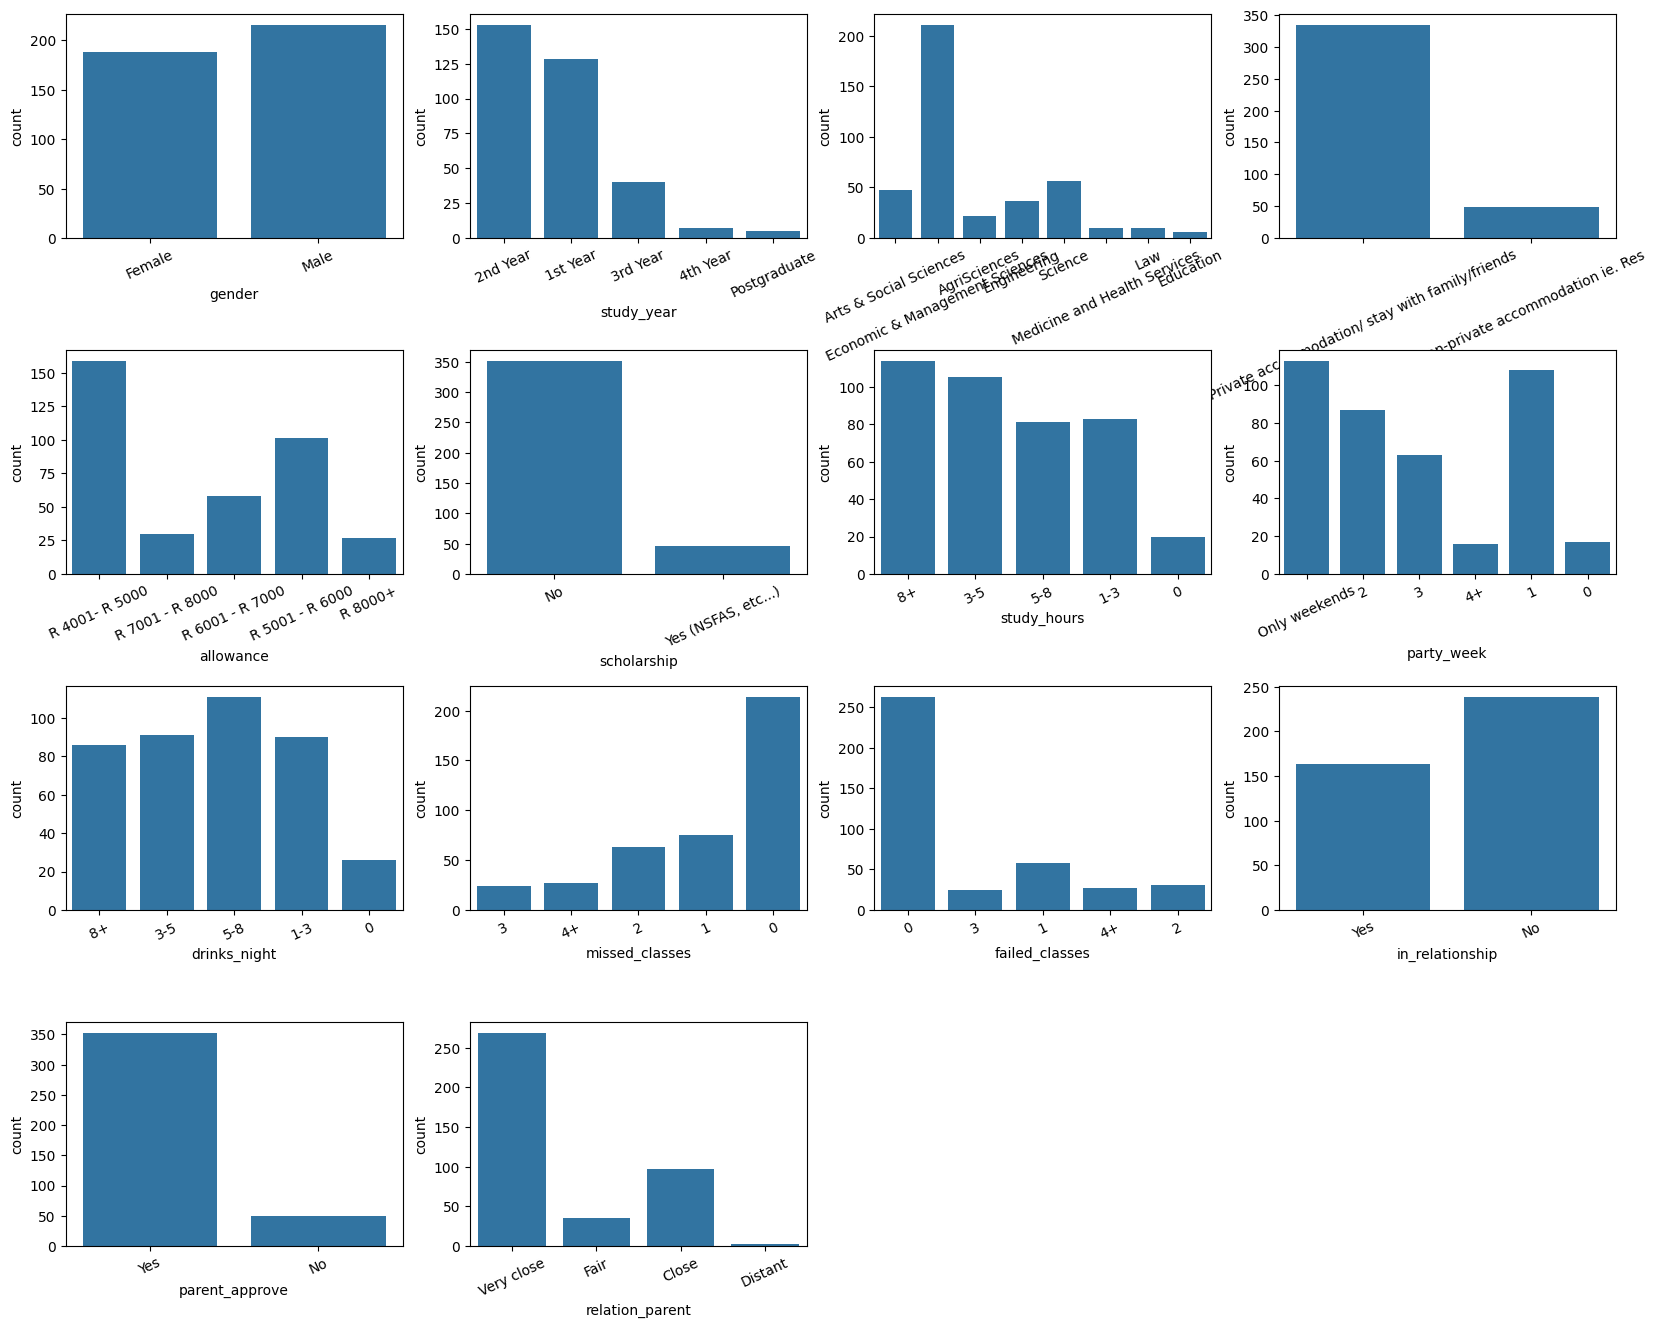

In [76]:
fig=plt.figure(figsize=(20,16))
sayac=1
for i in df.select_dtypes(include="object").columns:
    fig.add_subplot(4,4,sayac)
    sns.countplot(df,x=i)
    plt.xticks(rotation=25)
    sayac+=1
    plt.subplots_adjust(hspace=0.5)
plt.show()

Relation between Parent Approval and Parent Relationship

In [77]:
df.isna().sum()

gender              2
highschool_%        7
study_year         73
faculty             7
ung_grade_2023     86
accomodation       23
allowance          31
scholarship         8
study_hours         3
party_week          2
drinks_night        2
missed_classes      3
failed_classes      3
in_relationship     3
parent_approve      4
relation_parent     3
dtype: int64

In [78]:
df.drop_duplicates(inplace=True)

In [79]:
df=df.dropna(axis=0,thresh=8)

In [80]:
df.isna().sum()

gender              0
highschool_%        5
study_year         70
faculty             5
ung_grade_2023     83
accomodation       21
allowance          29
scholarship         6
study_hours         1
party_week          0
drinks_night        0
missed_classes      1
failed_classes      1
in_relationship     1
parent_approve      2
relation_parent     1
dtype: int64

In [81]:
df['accomodation'].unique()

array(['Private accommodation/ stay with family/friends', nan,
       'Non-private accommodation ie. Res'], dtype=object)

In [82]:
df['allowance'] = df['allowance'].fillna('Unknown')

In [83]:
df['allowance'].value_counts()

allowance
R 4001- R 5000     158
R 5001 - R 6000    100
R 6001 - R 7000     58
R 7001 - R 8000     30
Unknown             29
R 8000+             27
Name: count, dtype: int64

In [84]:
df['allowance'].isna().sum()

np.int64(0)

In [85]:
allowance_mapping = {
    'R 4001- R 5000': 0,
    'R 5001 - R 6000': 1,
    'R 6001 - R 7000': 2,
    'R 7001 - R 8000': 3,
    'R 8000+': 4,
    'Unknown': 5
}

df['allowance'] = df['allowance'].map(allowance_mapping)

In [86]:
df['allowance']

0      0
1      3
2      0
3      2
4      0
      ..
401    5
402    2
403    0
404    0
405    1
Name: allowance, Length: 402, dtype: int64

In [87]:

df.isna().sum()

gender              0
highschool_%        5
study_year         70
faculty             5
ung_grade_2023     83
accomodation       21
allowance           0
scholarship         6
study_hours         1
party_week          0
drinks_night        0
missed_classes      1
failed_classes      1
in_relationship     1
parent_approve      2
relation_parent     1
dtype: int64

In [88]:
df['scholarship'].value_counts()

scholarship
No                     351
Yes (NSFAS, etc...)     45
Name: count, dtype: int64

In [89]:
df['scholarship']=df['scholarship'].fillna(df['scholarship'].mode()[0])

In [90]:
df['scholarship']=df['scholarship'].map({
    'No':1,
    "Yes (NSFAS, etc...)":0

})

In [91]:
df['scholarship']

0      1
1      0
2      1
3      1
4      1
      ..
401    1
402    0
403    1
404    1
405    1
Name: scholarship, Length: 402, dtype: int64

In [92]:
df['study_hours'].value_counts()

study_hours
8+     113
3-5    104
1-3     83
5-8     81
0       20
Name: count, dtype: int64

In [93]:
study_hour_mapping = {
    '0': 0,
    '1-3': 1,
    '3-5': 2,
    '5-8': 3,
    '8+': 4
}

df['study_hours'] = df['study_hours'].map(study_hour_mapping)

In [94]:
df['study_hours']=df['study_hours'].fillna(df['study_hours'].mode()[0])

In [95]:
df['study_hours'].isna().sum()

np.int64(0)

In [96]:
party_mapping = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4+': 4,
    'Only weekends': 5
}

df['party_week'] = df['party_week'].astype(str).map(party_mapping)

In [97]:
df['drinks_night'].value_counts(dropna=False)

drinks_night
5-8    111
3-5     91
1-3     89
8+      85
0       26
Name: count, dtype: int64

In [98]:
drinks_nights_mapping = {
    '0': 0,
    '1-3': 1,
    '3-5': 2,
    '5-8': 3,
    '8+': 4
}

df['drinks_night'] = df['drinks_night'].astype(str).map(drinks_nights_mapping)

In [99]:
df['missed_classes'].value_counts()

missed_classes
0     214
1      74
2      63
4+     26
3      24
Name: count, dtype: int64

In [100]:
missed_class_mapping = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4+': 4
}

df['missed_classes'] = df['missed_classes'].astype(str).map(missed_class_mapping)

In [101]:
df['missed_classes']=df['missed_classes'].fillna(df['missed_classes'].mode()[0])

In [102]:
df['missed_classes'].isna().sum()

np.int64(0)

In [103]:
df['failed_classes'].value_counts()

failed_classes
0     261
1      58
2      31
4+     27
3      24
Name: count, dtype: int64

In [104]:
failed_class_mapping = {
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4+': 4
}

df['failed_classes'] = df['failed_classes'].astype(str).map(failed_class_mapping)

In [105]:
df['failed_classes']=df['failed_classes'].fillna(df['failed_classes'].mode()[0])

In [106]:
df['in_relationship'].value_counts()

in_relationship
No     239
Yes    162
Name: count, dtype: int64

In [107]:
df['in_relationship']=df['in_relationship'].fillna(df['in_relationship'].mode()[0])

In [108]:
df['in_relationship'] = df['in_relationship'].map({"Yes": 0, "No": 1})


In [109]:
df['in_relationship'].isna().sum()


np.int64(0)

In [110]:
df['parent_approve'].value_counts()

parent_approve
Yes    351
No      49
Name: count, dtype: int64

In [111]:
df['relation_parent'].value_counts()

relation_parent
Very close    267
Close          97
Fair           35
Distant         2
Name: count, dtype: int64

In [112]:
relation_parent_mapping={
    'Very close':0,
    'Close':1,
    'Fair':2,
    'Distant':3
}
df['relation_parent']=df['relation_parent'].map(relation_parent_mapping)

In [113]:
df['relation_parent']=df['relation_parent'].fillna(df['relation_parent'].mode()[0])


In [114]:
df['gender']=df['gender'].map({"Male":0,"Female":1})

In [115]:
df.study_year.value_counts()

study_year
2nd Year        152
1st Year        128
3rd Year         40
4th Year          7
Postgraduate      5
Name: count, dtype: int64

In [ ]:
# df['study_year'] = df['study_year'].str.strip()

In [ ]:
# study_year_mapping = {
#     "1st Year": 0,
#     "2nd Year": 1,
#     "3rd Year": 2,
#     "4th Year": 3,
#     "Postgraduate": 4
# }
# df['study_year'] = df['study_year'].astype(str).map(study_year_mapping)
 

In [118]:
faculty_mapping = {
    "AgriSciences": 0,
    "Arts & Social Sciences": 1,
    "Economic & Management Sciences": 2,
    "Education": 3,
    "Engineering": 4,
    "Law": 5,
    "Medicine & Health Sciences": 6,
    "Military Science": 7,
    "Science": 8,
    "Theology": 9
}
df['faculty'] = df['faculty'].map(faculty_mapping)

In [119]:
df.accomodation.value_counts()

accomodation
Private accommodation/ stay with family/friends    333
Non-private accommodation ie. Res                   48
Name: count, dtype: int64

In [120]:
df['accomodation']=df['accomodation'].fillna("Unknown")

In [121]:
df['accomodation']=df['accomodation'].map({
    "Private accommodation/ stay with family/friends": 0,
    "Non-private accommodation ie. Res" : 1,
    "Unknown" : 2
    })


In [122]:
df = df.dropna(subset=['ung_grade_2023'])

In [123]:
df.isna().sum()

gender              0
highschool_%        2
study_year          1
faculty            12
ung_grade_2023      0
accomodation        0
allowance           0
scholarship         0
study_hours         0
party_week          0
drinks_night        0
missed_classes      0
failed_classes      0
in_relationship     0
parent_approve      1
relation_parent     0
dtype: int64

In [ ]:
df['study_year']=df['study_year']

In [ ]:
columns = ['highschool_%', 'faculty','parent_approve','study_year']

df[columns] = df[columns].apply(
    lambda col: col.fillna(col.mode()[0]))

In [125]:
df.isna().sum()

gender             0
highschool_%       0
study_year         0
faculty            0
ung_grade_2023     0
accomodation       0
allowance          0
scholarship        0
study_hours        0
party_week         0
drinks_night       0
missed_classes     0
failed_classes     0
in_relationship    0
parent_approve     0
relation_parent    0
dtype: int64

In [126]:
df

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,1,76.0,1.0,1.0,72.0,0,0,1,4.0,5,4,3.0,0.0,0,Yes,0.0
1,0,89.0,1.0,2.0,75.0,0,3,0,4.0,5,2,4.0,0.0,1,Yes,0.0
2,0,76.0,0.0,0.0,55.0,0,0,1,2.0,2,4,3.0,0.0,1,Yes,0.0
3,0,89.0,1.0,4.0,84.0,0,2,1,2.0,3,4,2.0,0.0,0,Yes,0.0
4,1,74.0,1.0,1.0,52.0,0,0,1,2.0,5,3,1.0,3.0,1,Yes,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,1,78.0,1.0,2.0,74.0,0,0,1,1.0,5,1,0.0,0.0,1,Yes,0.0
397,0,86.0,0.0,2.0,70.0,0,0,1,3.0,2,2,2.0,0.0,0,Yes,2.0
398,1,74.0,1.0,2.0,60.0,0,2,1,3.0,5,1,0.0,3.0,1,No,1.0
402,1,73.0,1.0,2.0,58.0,0,2,0,3.0,1,4,0.0,0.0,0,Yes,0.0


In [127]:
df.parent_approve=df.parent_approve.map({
    "Yes":0,
    "No":1
})

In [128]:
df

,gender,highschool_%,study_year,faculty,ung_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,1,76.0,1.0,1.0,72.0,0,0,1,4.0,5,4,3.0,0.0,0,0,0.0
1,0,89.0,1.0,2.0,75.0,0,3,0,4.0,5,2,4.0,0.0,1,0,0.0
2,0,76.0,0.0,0.0,55.0,0,0,1,2.0,2,4,3.0,0.0,1,0,0.0
3,0,89.0,1.0,4.0,84.0,0,2,1,2.0,3,4,2.0,0.0,0,0,0.0
4,1,74.0,1.0,1.0,52.0,0,0,1,2.0,5,3,1.0,3.0,1,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,1,78.0,1.0,2.0,74.0,0,0,1,1.0,5,1,0.0,0.0,1,0,0.0
397,0,86.0,0.0,2.0,70.0,0,0,1,3.0,2,2,2.0,0.0,0,0,2.0
398,1,74.0,1.0,2.0,60.0,0,2,1,3.0,5,1,0.0,3.0,1,1,1.0
402,1,73.0,1.0,2.0,58.0,0,2,0,3.0,1,4,0.0,0.0,0,0,0.0


In [129]:
df.isna().sum()

gender             0
highschool_%       0
study_year         0
faculty            0
ung_grade_2023     0
accomodation       0
allowance          0
scholarship        0
study_hours        0
party_week         0
drinks_night       0
missed_classes     0
failed_classes     0
in_relationship    0
parent_approve     0
relation_parent    0
dtype: int64

In [130]:
X=df.drop('ung_grade_2023',axis=1)
y=df['ung_grade_2023']

In [131]:
from sklearn.preprocessing import StandardScaler


In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42   
)

In [133]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [134]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [136]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 7.28617744669221
MSE: 78.26945559479816
RMSE: 8.847002633366747
R² Score: 0.24533527141400058
